# **Managing Public Portfolios:  Factor mimicking portfolios**

The notebook produces  Figure 19


In [1]:
from IPython.display import HTML

#HTML('''<script>
#code_show=true; 
#function code_toggle() {
# if (code_show){
# $('div.input').hide();
# } else {
# $('div.input').show();
# }
# code_show = !code_show
#} 
#$( document ).ready(code_toggle);
#</script>
#<form action="javascript:code_toggle()"><input type="submit" value="Click here to toggle on/off the raw code."></form>''')

## Import libraries

In [2]:
import time,os,datetime,math,warnings
import pandas as pd
import numpy as np
import scipy as sp
from scipy import interpolate
import scipy.optimize as optimize
import matplotlib.pyplot as plt
import pandas_datareader as web
import statsmodels.api as sm
import statsmodels.formula.api as reg
from statsmodels.tsa import tsatools
from statsmodels.tsa.vector_ar.var_model  import VAR
import subprocess as sub
from sklearn.decomposition import PCA
from scipy.interpolate import interp1d

#matplotlib.rcdefaults()


warnings.filterwarnings('ignore')
freq='Q'
pd.core.common.is_list_like = pd.api.types.is_list_like
pd.options.display.float_format = '{:,.4f}'.format
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
draft_path = ""
#draft_path = "/Users/apb/Dropbox/2011RA/FiscalPolicy/begs/begs4/revision/figdata/"
#draft_path="C:/Users/admin\Dropbox/2011RA/FiscalPolicy/begs/begs4/revision/figdata/"




# DATA 
Sample period 1952-2017

In [3]:
start_year=1952
end_year=2017

### FRED
We download macrodata from FRED. The frequency is **quarterly**. Things can be aggregated to annual frequency if needed. We extract data on output, inflation, and several items of the goverment accounts from NIPA. The data is stored in "macrodata".

In [4]:
start = datetime.date(start_year,1,1)
end = datetime.date(end_year,12,31)
macrodata=web.DataReader(['A796RX0Q048SBEA','GDP','GDPDEF','CPIAUCSL','W006RC1Q027SBEA','A957RC1Q027SBEA','A955RC1Q027SBEA','B087RC1Q027SBEA','A074RC1Q027SBEA','W780RC1Q027SBEA','TB3MS','FDEFX',"UNRATE"], "fred",start,end).resample(freq).mean()
macrodata.columns = ['real_cons_nondurable','gdp_nominal','gdpdef','CPI','TotalCurrentTaxReceipts','ConsumptionExpenditures','ConsumptionExpendituresAll','TransferPaymentsToPersons','PersonalIncomeTaxReceipts','ContributionToSocialInsurance','TB3','DefenseSpending','unemp']

#macrodata=web.DataReader(['A796RX0Q048SBEA','GDP','GDPDEF','CPIAUCSL','W006RC1Q027SBEA','A957RC1Q027SBEA','B087RC1Q027SBEA','A074RC1Q027SBEA','W780RC1Q027SBEA','TB3MS','FDEFX','USREC','UNRATE','LTCYUK','A957RC1Q027SBEA','HQMCB2YR','HQMCB5YR','HQMCB10YR','DGS1','DGS2','DGS5','DGS10','AAA10Y','AAAFFM'], "fred",start,end).resample(freq).mean()
#macrodata.columns = ['real_cons_nondurable','gdp_nominal','gdpdef','CPI','TotalCurrentTaxReceipts','ConsumptionExpenditures','TransferPaymentsToPersons','PersonalIncomeTaxReceipts','ContributionToSocialInsurance','TB3','DefenseSpending','rec_ind','unemp','uk_console','fed_gexp','hqm2yr','hqm5yr','hqm10yr','tb1yr','tb2yr','tb5yr','tb10yr','AAA10yr','AAA3m']
start = datetime.date(start_year,6,1)

macrodata['cons']=1

# define inflation as rate of change of CPI
macrodata['inflation']=(np.log(macrodata['CPI'])-np.log(macrodata['CPI'].shift()))*100
rho_pi=macrodata.inflation.autocorr()
macrodata['inf_innov']=    (macrodata.inflation-rho_pi*macrodata.inflation.shift())/100
pi_bar=2.0/((freq=='A')*1.0+(freq=='Q')*4.0)

# definte a measure of output. Here we start with real GDP

macrodata['real_gdp']=(macrodata['gdp_nominal'])/macrodata['gdpdef']

cycle, trend = sm.tsa.filters.hpfilter(np.log(macrodata['real_gdp']), 1600)
macrodata['real_gdp_hp']=cycle
macrodata['real_gdp_trend']=trend


# Define terms for computing the primary deficits relative to output
# spending
macrodata['g']=(macrodata['ConsumptionExpenditures']+macrodata['TransferPaymentsToPersons'])
macrodata['real_g']=(macrodata['ConsumptionExpenditures']+macrodata['TransferPaymentsToPersons'])/macrodata['gdpdef']
macrodata['real_g_y']=macrodata['real_g']/macrodata['real_gdp']
macrodata['real_g_y']=macrodata['real_g_y']*100
macrodata['real_g_y']=macrodata['real_g']/macrodata['real_gdp']
macrodata['g_y']=macrodata['real_g_y']

# revenues
macrodata['real_R']=(macrodata['TotalCurrentTaxReceipts']+macrodata['ContributionToSocialInsurance'])/macrodata['gdpdef']
macrodata['R']=(macrodata['TotalCurrentTaxReceipts']+macrodata['ContributionToSocialInsurance'])
macrodata['real_R_y']=macrodata['real_R']/macrodata['real_gdp']
macrodata['real_R_y']=macrodata['real_R_y']*100
macrodata['R_y']=macrodata['real_R_y']


macrodata['real_deficits']=macrodata['real_g']-macrodata['real_R']
macrodata['deficits']=macrodata['g']-macrodata['R']

cycle, trend = sm.tsa.filters.hpfilter(macrodata['real_deficits'], 1600)
macrodata['real_deficits_hp']=cycle
macrodata['real_deficits_hptrend']=trend

cycle, trend = sm.tsa.filters.hpfilter(macrodata['deficits'], 1600)
macrodata['deficits_hp']=cycle
macrodata['deficits_hptrend']=trend
#macrodata['deficits_dt'] = sm.tsa.detrend(macrodata['deficits'], order=1)


macrodata['real_deficits_y']=macrodata['real_g_y']-macrodata['real_R_y']
macrodata['real_deficits_y_dm']=macrodata['real_deficits_y']-macrodata['real_deficits_y'].mean()


macrodata['deficits_y']=macrodata['g_y']-macrodata['R_y']
macrodata['deficits_y_dm']=macrodata['deficits_y']-macrodata['deficits_y'].mean()

# expost and ex-ante real risk-free rate
macrodata['expost_rf']=macrodata['TB3']/4-macrodata['inflation'].shift(-1)

macrodata['inflation_year']=(np.log(macrodata['CPI'])-np.log(macrodata['CPI'].shift(4)))*100
X=macrodata[['cons','TB3','inflation_year']]
Y=macrodata.expost_rf
model = sm.OLS(Y[4:-1],X[4:-1])
results = model.fit()
macrodata['exante_rf']=results.fittedvalues
macrodata['rf']=macrodata['exante_rf']
macrodata['nom_shortrate']=macrodata.TB3/4



lag=0
macrodata["nom_shortrate_lag1"]=macrodata["nom_shortrate"].shift()
macrodata["nom_shortrate_lead1"]=macrodata["nom_shortrate"].shift(-1)

macrodata["unemp_lag"]=macrodata["unemp"].shift()
sel=(macrodata.nom_shortrate.notnull())&(macrodata.unemp_lag.notnull())
Y = macrodata[sel]["nom_shortrate"]
X = macrodata[sel][['cons', 'nom_shortrate_lag1','unemp_lag','unemp']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
#print(results.summary())
macrodata["nom_shortrate_news"]=results.resid
lag=0
macrodata["nom_shortrate_lag1"]=macrodata["nom_shortrate"].shift()
macrodata["nom_shortrate_lead1"]=macrodata["nom_shortrate"].shift(-1)
sel=(macrodata.nom_shortrate.notnull())&(macrodata.unemp_lag.notnull())
Y = macrodata[sel]["nom_shortrate"]
X = macrodata[sel][['cons', 'nom_shortrate_lag1']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
#print(results.summary())
macrodata["nom_shortrate_news"]=results.resid



### CRSP data

In [ ]:
fama_portfolio = pd.read_csv('../Data/fama_portfolio_2018.csv')


### Tax rates data (from Barro Redlick)


In [6]:
start_tax=datetime.date(1946,12,31)
end_tax = datetime.date(2017,12,31)
taxdata=pd.read_excel('../Data/barrotaxdata.xls')
taxdata.index=pd.date_range(start=start_tax,end=end_tax,freq='12M')
taxdata=taxdata[taxdata.index.year>=start.year]

### Bond yield data

In [7]:
feds=pd.read_csv('../Data/feds200628.csv',skiprows=9,index_col=0,parse_dates=True)
colnames=['SVENY'+ str(n+1).zfill(2) for n in range(15) ]
feds[colnames].describe().T

,count,mean,std,min,25%,50%,75%,max
SVENY01,"15,638.0000",4.8268,3.3048,0.0554,2.2020,4.9046,6.7434,16.4620
SVENY02,"15,638.0000",5.0312,3.2465,0.1020,2.5454,4.9714,6.9708,15.9118
SVENY03,"15,638.0000",5.1978,3.1767,0.1272,2.7559,5.1094,7.1520,15.5746
SVENY04,"15,638.0000",5.3390,3.1081,0.1685,2.9598,5.2355,7.2559,15.3498
SVENY05,"15,638.0000",5.4616,3.0455,0.2218,3.2282,5.3498,7.3450,15.1776
SVENY06,"15,638.0000",5.5690,2.9905,0.2806,3.4836,5.4440,7.4140,15.0611
SVENY07,"15,638.0000",5.6634,2.9430,0.3413,3.6743,5.5238,7.4668,15.0109
SVENY08,"13,102.0000",5.8757,3.1123,0.4020,3.3609,5.9265,7.8205,14.9799
SVENY09,"13,102.0000",5.9608,3.0721,0.4618,3.5194,5.9937,7.8556,14.9572
SVENY10,"13,102.0000",6.0357,3.0378,0.5202,3.6747,6.0600,7.8841,14.9398


## Description  terms in the government budget constraint

#### Real Governemnt Spending (Federal)
To construct expenditures we use the quarterly series of Federal Consumption Expenditures + Federal TransferPaymentsToPersons deflated by GDP deflator

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'real govt. spending'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'spending by GDP'}, xlabel='DATE'>

count   264.0000
mean      0.1457
std       0.0128
min       0.1213
25%       0.1373
50%       0.1442
75%       0.1511
max       0.1856
Name: real_g_y, dtype: float64

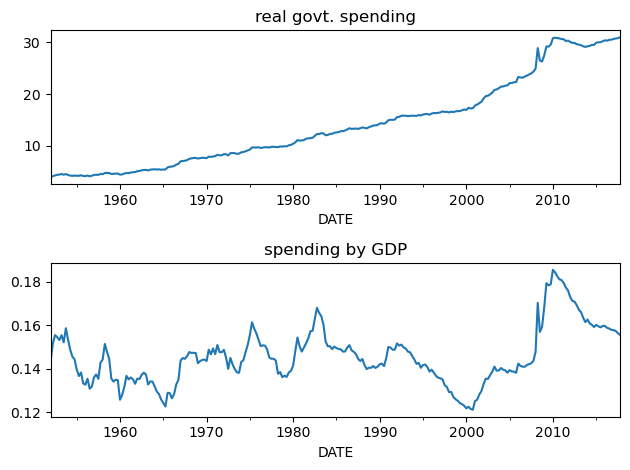

In [8]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['real_g'].plot(title='real govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['real_g_y'].plot(ax=plt.gca(),title='spending by GDP');
plt.tight_layout()
macrodata['real_g_y'].describe()

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. spending'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'spending by GDP'}, xlabel='DATE'>

count   264.0000
mean      0.1457
std       0.0128
min       0.1213
25%       0.1373
50%       0.1442
75%       0.1511
max       0.1856
Name: g_y, dtype: float64

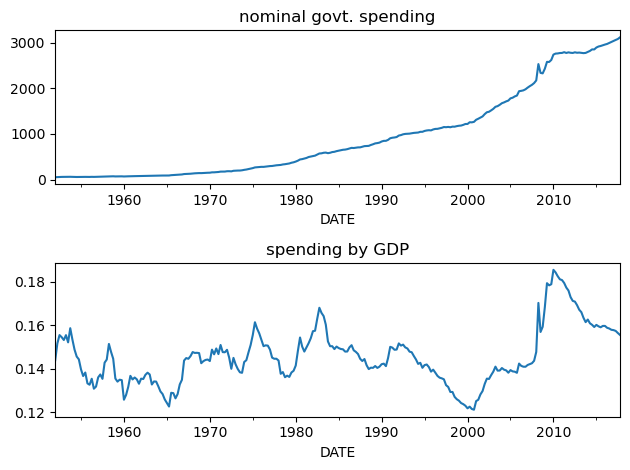

In [9]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['g'].plot(title='nominal govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['g_y'].plot(ax=plt.gca(),title='spending by GDP');
plt.tight_layout()
macrodata['g_y'].describe()

### Detrended Nominal Governemnt Spending (Federal)
We extract a linear trend from log nominal spending

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. spending'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'nominal govt. spending detrended'}, xlabel='DATE'>

count   264.0000
mean      0.0000
std      17.0178
min     -36.0894
25%      -9.8462
50%      -4.3743
75%      12.3071
max      34.7007
Name: ln_g_dt, dtype: float64

0.9926229724647988

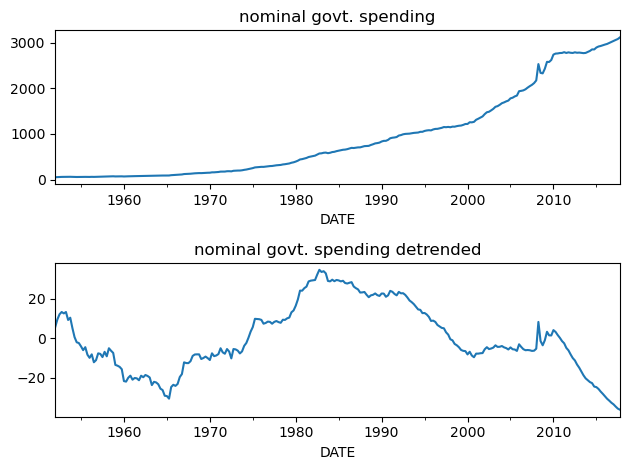

In [10]:
detrended_ln_g = sm.tsa.detrend(np.log(macrodata['g']), order=1)

macrodata['ln_g_dt']=detrended_ln_g *100
plt.figure(1)
plt.subplot(2,1,1)
macrodata['g'].plot(title='nominal govt. spending');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['ln_g_dt'].plot(ax=plt.gca(),title='nominal govt. spending detrended');
plt.tight_layout()

macrodata['ln_g_dt'].describe()
macrodata['ln_g_dt'].autocorr()

### Governemnt Nominal  Revenues (Federal)
We construct Revenues as  Nominal Federal TotalCurrentTaxReceipts +Federal'ContributionToSocialInsurance'

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'nominal govt. revenues'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'revenues by GDP'}, xlabel='DATE'>

count   264.0000
mean     16.9515
std       0.9768
min      14.2183
25%      16.4549
50%      16.9389
75%      17.5132
max      19.6108
Name: R_y, dtype: float64

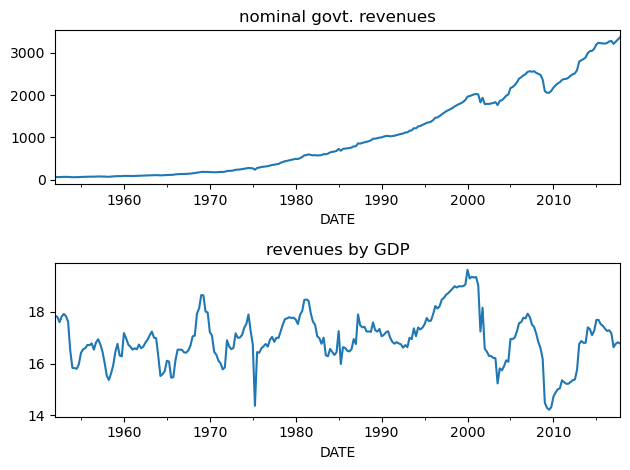

In [11]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['R'].plot(title='nominal govt. revenues');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['R_y'].plot(ax=plt.gca(),title='revenues by GDP');
plt.tight_layout()

macrodata['R_y'].describe()

### Nominal Primary deficit (Federal)
We construct Deficits are defined expenditures minus revenues.

<Figure size 640x480 with 0 Axes>

<Axes: >

<Axes: title={'center': 'real primary deficits'}, xlabel='DATE'>

<Axes: >

<Axes: title={'center': 'deficits by GDP'}, xlabel='DATE'>

count   264.0000
mean    -16.8059
std       0.9829
min     -19.4889
25%     -17.3675
50%     -16.7936
75%     -16.3142
max     -14.0399
Name: deficits_y, dtype: float64

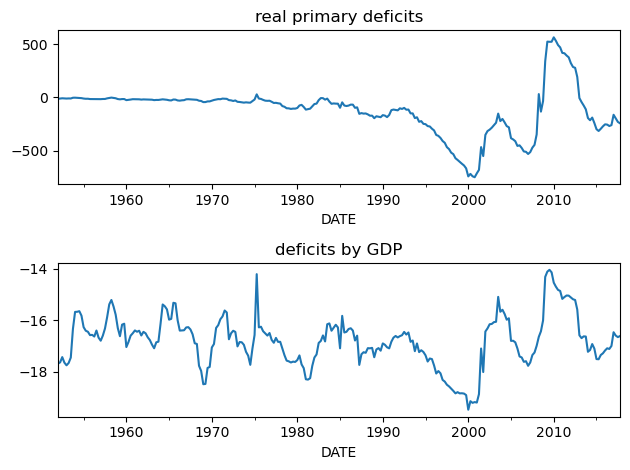

In [12]:
plt.figure(1)
plt.subplot(2,1,1)
macrodata['deficits'].plot(title='real primary deficits');#no need to specify for first axis
plt.subplot(2,1,2)
macrodata['deficits_y'].plot(ax=plt.gca(),title='deficits by GDP');
plt.tight_layout()

macrodata['deficits_y'].describe()

### Constructing $\frac{X_t}{\overline{y}_t}$

In this section, we construct a series for deficits relative to output trend. 

The deficits are divided by a seriers $\overline{y}_t$ that is simply the trend in GDP extracted by assuming a constant growth in logs, that is, $\overline{y_t}$ satisfies

$$ \log\text{real_gdp}_t =\underbrace{g_y t+\log y_0}_{\log{\overline{y}_t}}+ \log{\text{ deviations from trend}_t} $$


### Output trend $\overline{y}_t$

<Axes: xlabel='DATE'>

Growth rate per quarter % = 0.7771052895013658


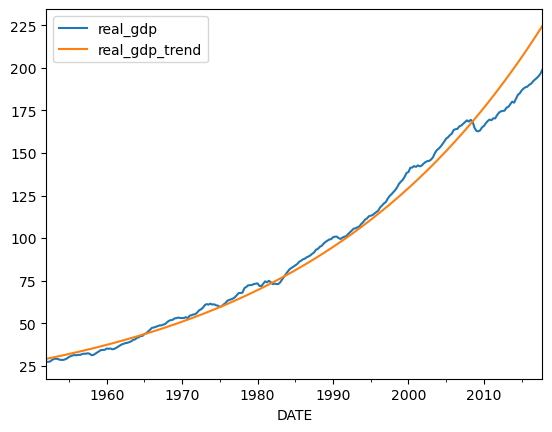

In [13]:
detrended_log_gdp = sm.tsa.detrend(np.log(macrodata['real_gdp']), order=1)
#detrended_log_gdp.plot()
log_trend=np.log(macrodata['real_gdp'])-detrended_log_gdp
y_trend=np.exp(log_trend)
macrodata['real_gdp_trend']=y_trend
macrodata['ln_real_gdp_dt']=detrended_log_gdp
gy=(log_trend-log_trend.shift()).mean()

#gy =0.0
macrodata[['real_gdp','real_gdp_trend']].plot()

print('Growth rate per quarter % = ' + str(gy*100))


<Axes: xlabel='DATE'>

Growth rate per quarter % = 1.676796473026158


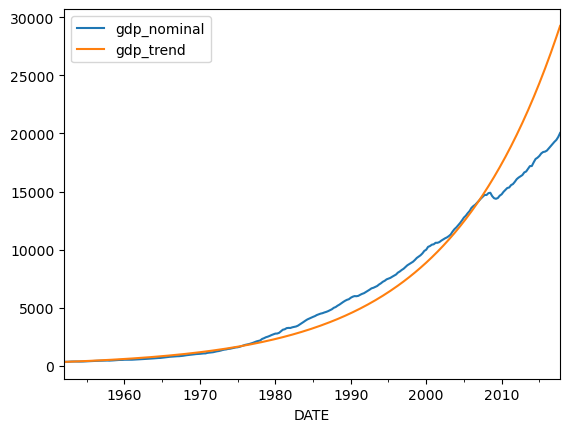

In [14]:
detrended_log_gdp = sm.tsa.detrend(np.log(macrodata['gdp_nominal']), order=1)
#detrended_log_gdp.plot()
log_trend=np.log(macrodata['gdp_nominal'])-detrended_log_gdp
y_trend=np.exp(log_trend)
macrodata['gdp_trend']=y_trend
macrodata['ln_gdp_dt']=detrended_log_gdp
gy=(log_trend-log_trend.shift()).mean()

#gy =0.0
macrodata[['gdp_nominal','gdp_trend']].plot()
print('Growth rate per quarter % = ' + str(gy*100))


### Constructed series for  $\frac{X_t}{\overline{y}_t}$

<Axes: xlabel='DATE'>

,deficits_y,deficits_dt
count,264.0000,264.0000
mean,-16.8059,-2.5279
std,0.9829,2.0603
min,-19.4889,-8.3471
25%,-17.3675,-3.4904
50%,-16.7936,-2.5877
75%,-16.3142,-1.5343
max,-14.0399,3.2538


,deficits_y,deficits_dt
deficits_y,1.0000,0.8454
deficits_dt,0.8454,1.0000


0.957983144011151

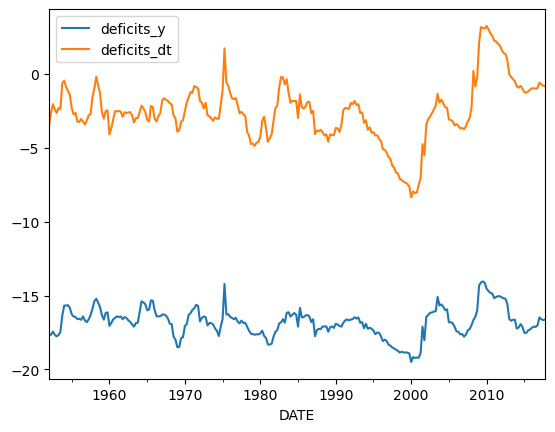

In [15]:
macrodata['deficits_dt']=(macrodata['deficits']/y_trend)*100
macrodata['deficits_dt_dm']=macrodata['deficits_dt']-macrodata['deficits_dt'].mean()
macrodata[['deficits_y','deficits_dt']].plot()
macrodata[['deficits_y','deficits_dt']].describe()
macrodata[['deficits_y','deficits_dt']].corr()
macrodata['deficits_dt'].autocorr()

### Tax rate 
We take away the trend using a HP filter


<Axes: xlabel='DATE'>

tau_alt   0.0167
tau       0.0139
dtype: float64

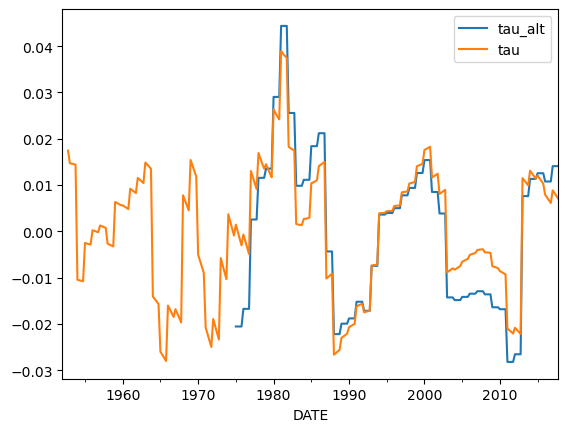

In [16]:

temp=taxdata.tau.resample('Q').bfill().reset_index()
temp.set_index(temp['index'],inplace=True)

cycle, trend = sm.tsa.filters.hpfilter(temp.tau,100000)
temp["cycle"] = cycle
temp["trend"] = trend

macrodata['tau_raw']=temp['cycle']+temp["trend"]
macrodata['tau']=temp.cycle+taxdata['tau'].mean()
macrodata['tau_alt']=macrodata['tau_raw'].values
macrodata.loc[macrodata.index.year<1975,'tau_alt']=np.nan
(macrodata[['tau_alt','tau']]-macrodata[['tau_alt','tau']].mean()).plot()
macrodata[macrodata.index.year>1974][['tau_alt','tau']].std()

### detreded TFP 
We construct the detreded TFP $\hat{\theta}_t$ using the expression

$$ \hat{\theta}_t = \widehat{\log(Y)}_t - \gamma \log(1-\overline{\tau}_{t})

<Axes: xlabel='DATE'>

count   261.0000
mean     17.9623
std      17.2717
min     -19.3580
25%       4.1563
50%      17.2976
75%      34.0305
max      45.3349
Name: theta, dtype: float64

0.9979097041854719

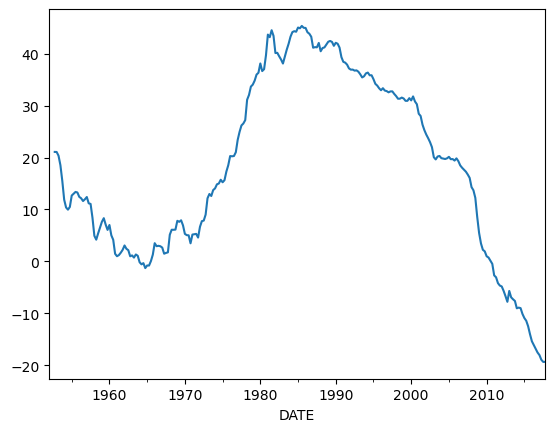

In [17]:
tau_bar=macrodata.tau.mean()
gamma=0.5

macrodata['theta']=macrodata['ln_gdp_dt'] -gamma*np.log(1-macrodata['tau'])

macrodata['theta']=macrodata['theta']*100
macrodata['theta'].plot()
macrodata['theta'].describe()
macrodata['theta'].autocorr()


##  Description of interpolated Yield Curve $Q^t_T$ 

We want to  discount with some version of $Q^t_T$. 

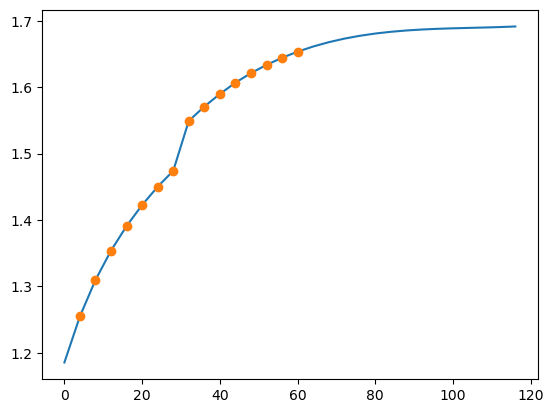

In [18]:
sel=(feds.index.year<2018)&(feds.index.year>1952)
#y=(feds.loc[sel,colnames].mean()/4)
# I want to fit a function to this data and then use it to interpolate the yields for the missing maturities
# I will use a cubic spline
x=np.array([4*k for k in range(1,15+1)])
y=feds.loc[sel,colnames].mean().values
y=((1+y/100)**(1/4)-1)*100
func_feds_mean = interp1d(x, y,kind='cubic',fill_value='extrapolate')

#define a function func_feds_mean that interpolates the yield curve and sets it 
# the value at 120 quarters for maturities more than 120 quarters

# def func_feds_mean(n):
#     if n<15*4+1:
#         y=func_feds_intr(n)
#     else:
#         y=func_feds_intr(15*4)
#     return y   

feds_mean=np.array([ func_feds_mean(n)  for  n in range(0,120,4)])
#plot the interpolated yield curve and compare it to the original data
plt.plot(range(0,120,4),feds_mean)
plt.plot(x,y,'o')
QT=lambda n: np.exp(-n*func_feds_mean(n)/100)   

# save the data as a csv file to be used to create a tikz plot
feds_mean=pd.DataFrame(feds_mean)
feds_mean.columns=['yield']
# add a column for the maturities
feds_mean['Maturities']=np.array([n for n in range(0,120,4)])
# add a column for the discount factors
feds_mean['DiscountFactor']=QT(feds_mean['Maturities'])
# save the data as a csv file
feds_mean.to_csv(draft_path+'feds_mean.csv')




## Description of Bond returns

This is the decription from CRSP: The Fama Maturity Portfolios are defined in 6-month intervals (TREASNOX range 2000028–2000037) and in 12-month intervals (TREASNOX range 2000040–2000044) for up to 60 months. TREASNOX 2000038 is a single portfolio for maturities between 60 and 120 months, and TREASNOX 2000039 is a single portfolio for maturities greater than 120 months. Each TREASNOX represents the portfolio containing one-month holding period returns for issues maturing in a range of months from the quote date. Callable, non-callable, and non-flower notes and bonds are included in the portfolios. Partially and full tax-exempt issues are excluded. The returns are calculated as the equal-weighted average of the unadjusted holding period return (TMRETNUA) for each bond in the portfolio. For our analysis we use hprXX where $XX  \in \{1,2,3,4,5, 510\}$ are maturities. 



In [19]:
def get_returns_ff(key,var_name,fama_portfolio):
    long_return=pd.DataFrame([fama_portfolio[fama_portfolio['KYTREASNOX']==key]['TMEWRETD'].values])
    long_return=long_return.T
    long_return['qdate'] = pd.date_range('1952-01-31',periods = len(long_return), freq='M')
    long_return.set_index('qdate',inplace=True)
    long_return.columns=[var_name]
    return pd.DataFrame(long_return.resample(freq).sum())*100

def adjust_real_hpr(n,inflation):
    inflation=inflation-inflation.mean()
    rho_pi=inflation.autocorr()
    factor=( (rho_pi/(1-rho_pi) )* (1-rho_pi**(n-1)) )* (inflation.shift(-1)-rho_pi*inflation)
    return factor




def construct_real_excess_returns(n,hpr,nom_rate):
    hprx=(hpr-nom_rate)
    #maturity=n*((freq=='A')*1.0+(freq=='Q')*4.0)
    # hprx=hprx+adjust_real_hpr(maturity,macrodata.inflation)
    return hprx
    

### Inflation adjustment 
In our baseline we want to use the real excess holding period return on nominal bonds. Since the inflation term will be in both the return on long bond and the risk-free rate, it will be cancelled. So no inflation adjustment is necessary

In [20]:
#fama_portfolio = pd.read_csv('fama_portfolio_2018.csv')
nom_returns = pd.DataFrame(macrodata['nom_shortrate'])
return_list = []
for mat in range(6, 66, 6):
    ret = get_returns_ff(2000027+mat/6, 'ret', fama_portfolio)
    nom_returns['hprx'+str(mat)+'m'] = ret
    macrodata['hprx'+str(mat)+'m'] = construct_real_excess_returns(mat /
                                                                   12.0, ret.ret, macrodata['nom_shortrate'])
    return_list.append('hprx'+str(mat)+'m')

hpr510yr = get_returns_ff(2000038, 'hpr510yr', fama_portfolio)
hpr10plusyr = get_returns_ff(2000039, 'hpr10plusyr', fama_portfolio)
macrodata['hprx510yr'] = construct_real_excess_returns(
    7.5, hpr510yr.hpr510yr, macrodata['nom_shortrate'])
macrodata['hprx10plusyr'] = construct_real_excess_returns(
    15.0, hpr10plusyr.hpr10plusyr, macrodata['nom_shortrate'])

nom_returns['hprx40Q'] = hpr510yr

macrodata['rf_lag'] = macrodata['rf'].shift()
return_list.append('hprx510yr')
return_list.append('hprx10plusyr')


#col_rename_dict = {i: j for i, j in zip(nom_returns.columns, yields_mat)}
#nom_returns.rename(columns=col_rename_dict, inplace=True)


### Constructing Table 1

In [21]:
col_rename_dict = {i: j for i, j in zip(nom_returns.columns, ['{}m'.format(3*k) for k in np.hstack((np.hstack(([1], [j for j in range(2, 21, 2)])),40))])}
nom_returns.rename(columns=col_rename_dict, inplace=True)



#### Time series for returns

array([[<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>],
       [<Axes: xlabel='DATE'>, <Axes: xlabel='DATE'>]], dtype=object)

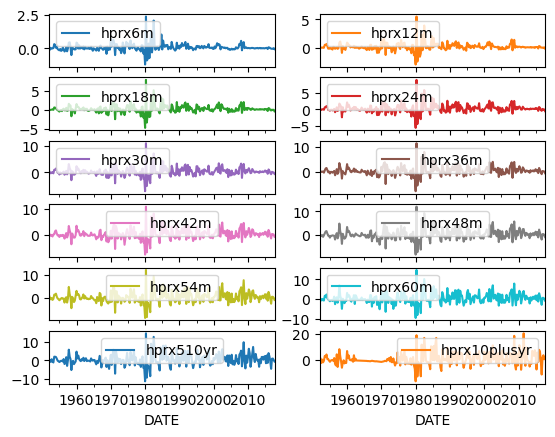

In [22]:
macrodata[return_list].plot(subplots=True,layout=(6,2))

## Construct the first principal component of returns $f_t$
It turned out that the CP factor did not explain much of our holding period returns. Therefore I decided to try the first principal compnent

explained variation
[0.90961948]


<Axes: xlabel='DATE'>

sigma2_f
63.30751526180667


DATE
1952-03-31        NaN
1952-06-30        NaN
1952-09-30        NaN
1952-12-31        NaN
1953-03-31    -3.4130
               ...   
2016-12-31   -12.7861
2017-03-31        NaN
2017-06-30        NaN
2017-09-30        NaN
2017-12-31        NaN
Freq: Q-DEC, Name: factor, Length: 264, dtype: float64

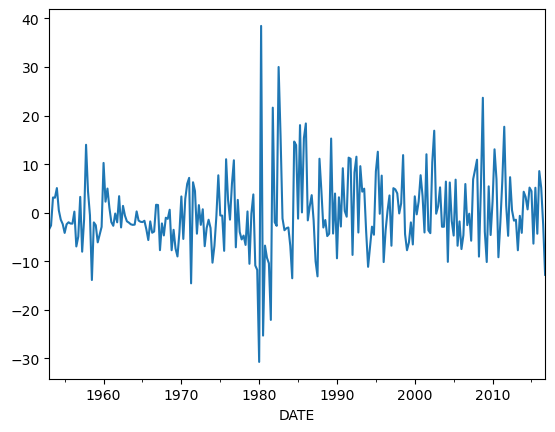

In [23]:
data=macrodata[(macrodata.index.year>start_year)&(macrodata.index.year<end_year) ]

#factornamelist=return_list+ ['deficits_y','nom_shortrate','log_gdp_dt'] 

factornamelist =  return_list

pca = PCA(n_components=1)
principalComponents = pca.fit_transform(data[factornamelist])
pair_of_return=return_list[:-1]

print ("explained variation")
print (pca.explained_variance_ratio_)

#data['factor']=macrodata["real_gdp"]/macrodata["real_gdp"].shift(4)-1
data['factor']=principalComponents
data['factor'].plot()
print ("sigma2_f")
print (data['factor'].var())
macrodata['factor']=data.factor
macrodata['factor']
#create a column "dateaalt" that reads year.quarter/4 in the format 1952.0,1952.25 and so on
macrodata['datealt']=macrodata.index.year+macrodata.index.quarter/4.0
macrodata[['datealt','factor']].to_csv(draft_path+'factordata.csv')


In [24]:
macrodata[return_list+['deficits_dt','nom_shortrate','nom_shortrate_news','nom_shortrate_lead1']].describe().T

,count,mean,std,min,25%,50%,75%,max
hprx6m,264.0000,0.0757,0.3030,-1.1931,-0.0404,0.0321,0.1640,2.3668
hprx12m,264.0000,0.1423,0.7020,-2.9796,-0.1110,0.0486,0.3495,5.4777
hprx18m,264.0000,0.2028,1.0622,-4.7757,-0.2605,0.0805,0.5105,7.8365
hprx24m,264.0000,0.2270,1.3472,-5.7238,-0.4632,0.0909,0.7028,9.0635
hprx30m,264.0000,0.2635,1.6803,-7.1693,-0.5820,0.0762,0.8725,10.9599
hprx36m,264.0000,0.3006,1.9097,-8.0650,-0.6526,0.0825,1.0383,11.5576
hprx42m,264.0000,0.3270,2.1035,-7.7213,-0.7602,0.0884,1.3015,10.9855
hprx48m,264.0000,0.3313,2.3135,-8.2436,-0.9198,-0.0229,1.3716,11.9944
hprx54m,264.0000,0.3552,2.4678,-8.5431,-1.0041,-0.0017,1.5461,11.9771
hprx60m,264.0000,0.2880,2.7901,-9.7209,-1.2256,-0.0544,1.7302,14.7989


In [25]:
macrodata[return_list+['deficits_y','nom_shortrate','nom_shortrate_news','nom_shortrate_lead1']].describe().T

,count,mean,std,min,25%,50%,75%,max
hprx6m,264.0000,0.0757,0.3030,-1.1931,-0.0404,0.0321,0.1640,2.3668
hprx12m,264.0000,0.1423,0.7020,-2.9796,-0.1110,0.0486,0.3495,5.4777
hprx18m,264.0000,0.2028,1.0622,-4.7757,-0.2605,0.0805,0.5105,7.8365
hprx24m,264.0000,0.2270,1.3472,-5.7238,-0.4632,0.0909,0.7028,9.0635
hprx30m,264.0000,0.2635,1.6803,-7.1693,-0.5820,0.0762,0.8725,10.9599
hprx36m,264.0000,0.3006,1.9097,-8.0650,-0.6526,0.0825,1.0383,11.5576
hprx42m,264.0000,0.3270,2.1035,-7.7213,-0.7602,0.0884,1.3015,10.9855
hprx48m,264.0000,0.3313,2.3135,-8.2436,-0.9198,-0.0229,1.3716,11.9944
hprx54m,264.0000,0.3552,2.4678,-8.5431,-1.0041,-0.0017,1.5461,11.9771
hprx60m,264.0000,0.2880,2.7901,-9.7209,-1.2256,-0.0544,1.7302,14.7989


## Summary Statistics for returns and deficits (detrended)

In [26]:
macrodata[return_list+['deficits_dt','nom_shortrate','nom_shortrate_news','nom_shortrate_lead1']].describe().T

,count,mean,std,min,25%,50%,75%,max
hprx6m,264.0000,0.0757,0.3030,-1.1931,-0.0404,0.0321,0.1640,2.3668
hprx12m,264.0000,0.1423,0.7020,-2.9796,-0.1110,0.0486,0.3495,5.4777
hprx18m,264.0000,0.2028,1.0622,-4.7757,-0.2605,0.0805,0.5105,7.8365
hprx24m,264.0000,0.2270,1.3472,-5.7238,-0.4632,0.0909,0.7028,9.0635
hprx30m,264.0000,0.2635,1.6803,-7.1693,-0.5820,0.0762,0.8725,10.9599
hprx36m,264.0000,0.3006,1.9097,-8.0650,-0.6526,0.0825,1.0383,11.5576
hprx42m,264.0000,0.3270,2.1035,-7.7213,-0.7602,0.0884,1.3015,10.9855
hprx48m,264.0000,0.3313,2.3135,-8.2436,-0.9198,-0.0229,1.3716,11.9944
hprx54m,264.0000,0.3552,2.4678,-8.5431,-1.0041,-0.0017,1.5461,11.9771
hprx60m,264.0000,0.2880,2.7901,-9.7209,-1.2256,-0.0544,1.7302,14.7989


In [27]:
macrodata[return_list+['deficits_dt','nom_shortrate','unemp','nom_shortrate_news','nom_shortrate_lead1']].corr()

,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,hprx10plusyr,deficits_dt,nom_shortrate,unemp,nom_shortrate_news,nom_shortrate_lead1
hprx6m,1.0000,0.9479,0.9049,0.8715,0.8434,0.8266,0.7901,0.7626,0.7489,0.7207,0.7101,0.5511,0.0211,0.0795,0.1428,-0.6769,-0.0039
hprx12m,0.9479,1.0000,0.9816,0.9624,0.9415,0.9232,0.8995,0.8733,0.8595,0.8378,0.8218,0.6480,0.0702,-0.0334,0.1548,-0.6915,-0.1157
hprx18m,0.9049,0.9816,1.0000,0.9820,0.9678,0.9579,0.9393,0.9143,0.9024,0.8835,0.8675,0.6915,0.0766,-0.0254,0.1718,-0.6595,-0.1034
hprx24m,0.8715,0.9624,0.9820,1.0000,0.9842,0.9771,0.9686,0.9474,0.9389,0.9236,0.9064,0.7398,0.0944,-0.0650,0.1652,-0.6365,-0.1417
hprx30m,0.8434,0.9415,0.9678,0.9842,1.0000,0.9849,0.9778,0.9616,0.9509,0.9428,0.9257,0.7616,0.0896,-0.0784,0.1586,-0.6073,-0.1502
hprx36m,0.8266,0.9232,0.9579,0.9771,0.9849,1.0000,0.9862,0.9741,0.9653,0.9492,0.9417,0.7870,0.1004,-0.0825,0.1699,-0.5938,-0.1555
hprx42m,0.7901,0.8995,0.9393,0.9686,0.9778,0.9862,1.0000,0.9870,0.9787,0.9619,0.9597,0.8063,0.1036,-0.0904,0.1706,-0.5645,-0.1662
hprx48m,0.7626,0.8733,0.9143,0.9474,0.9616,0.9741,0.9870,1.0000,0.9792,0.9637,0.9678,0.8311,0.1055,-0.0980,0.1651,-0.5599,-0.1720
hprx54m,0.7489,0.8595,0.9024,0.9389,0.9509,0.9653,0.9787,0.9792,1.0000,0.9683,0.9707,0.8446,0.1103,-0.1030,0.1473,-0.5222,-0.1771
hprx60m,0.7207,0.8378,0.8835,0.9236,0.9428,0.9492,0.9619,0.9637,0.9683,1.0000,0.9659,0.8526,0.1079,-0.1062,0.1600,-0.5245,-0.1741


In [28]:
macrodata[return_list+['deficits_y','nom_shortrate','unemp','nom_shortrate_news','nom_shortrate_lead1']].corr()

,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,hprx10plusyr,deficits_y,nom_shortrate,unemp,nom_shortrate_news,nom_shortrate_lead1
hprx6m,1.0000,0.9479,0.9049,0.8715,0.8434,0.8266,0.7901,0.7626,0.7489,0.7207,0.7101,0.5511,-0.0102,0.0795,0.1428,-0.6769,-0.0039
hprx12m,0.9479,1.0000,0.9816,0.9624,0.9415,0.9232,0.8995,0.8733,0.8595,0.8378,0.8218,0.6480,0.0640,-0.0334,0.1548,-0.6915,-0.1157
hprx18m,0.9049,0.9816,1.0000,0.9820,0.9678,0.9579,0.9393,0.9143,0.9024,0.8835,0.8675,0.6915,0.0759,-0.0254,0.1718,-0.6595,-0.1034
hprx24m,0.8715,0.9624,0.9820,1.0000,0.9842,0.9771,0.9686,0.9474,0.9389,0.9236,0.9064,0.7398,0.0990,-0.0650,0.1652,-0.6365,-0.1417
hprx30m,0.8434,0.9415,0.9678,0.9842,1.0000,0.9849,0.9778,0.9616,0.9509,0.9428,0.9257,0.7616,0.0975,-0.0784,0.1586,-0.6073,-0.1502
hprx36m,0.8266,0.9232,0.9579,0.9771,0.9849,1.0000,0.9862,0.9741,0.9653,0.9492,0.9417,0.7870,0.1045,-0.0825,0.1699,-0.5938,-0.1555
hprx42m,0.7901,0.8995,0.9393,0.9686,0.9778,0.9862,1.0000,0.9870,0.9787,0.9619,0.9597,0.8063,0.1116,-0.0904,0.1706,-0.5645,-0.1662
hprx48m,0.7626,0.8733,0.9143,0.9474,0.9616,0.9741,0.9870,1.0000,0.9792,0.9637,0.9678,0.8311,0.1159,-0.0980,0.1651,-0.5599,-0.1720
hprx54m,0.7489,0.8595,0.9024,0.9389,0.9509,0.9653,0.9787,0.9792,1.0000,0.9683,0.9707,0.8446,0.1161,-0.1030,0.1473,-0.5222,-0.1771
hprx60m,0.7207,0.8378,0.8835,0.9236,0.9428,0.9492,0.9619,0.9637,0.9683,1.0000,0.9659,0.8526,0.1102,-0.1062,0.1600,-0.5245,-0.1741


#### Covariances of returns and deficits

In [29]:
variables = ['deficits_dt', 'tau','nom_shortrate','nom_shortrate_news','nom_shortrate_lead1']
#macrodata = macrodata.join(lpdata_yields_interpolated)

In [30]:
rescal_mat = macrodata[return_list[0:-1]+variables]
rescal_mat['tau'] = rescal_mat['tau']*100
#rescal_mat['Yield_3m'] = rescal_mat['Yield_3m']
rescal_mat['nom_shortrate'] = rescal_mat['nom_shortrate']
rescal_mat['nom_shortrate_news'] = rescal_mat['nom_shortrate_news']
rescal_mat['nom_shortrate_lead1'] = rescal_mat['nom_shortrate_lead1']

rescal_mat['surplus'] = -rescal_mat['deficits_dt']
cov_mat = rescal_mat.cov()
cov_mat.where(np.triu(np.ones(cov_mat.shape)).astype(bool)).to_csv(
    'covariances_returns_deficits_no_adjust.csv', float_format='%.2g')
cov_mat.where(np.triu(np.ones(cov_mat.shape)).astype(bool))


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,nom_shortrate,nom_shortrate_news,nom_shortrate_lead1,surplus
hprx6m,0.0918,0.2017,0.2913,0.3558,0.4295,0.4784,0.5037,0.5346,0.5600,0.6094,0.6894,0.0132,0.0167,0.0186,-0.0353,-0.0009,-0.0132
hprx12m,NaN,0.4928,0.7320,0.9103,1.1106,1.2377,1.3282,1.4184,1.4891,1.6411,1.8481,0.1016,-0.0214,-0.0181,-0.0837,-0.0627,-0.1016
hprx18m,NaN,NaN,1.1282,1.4053,1.7273,1.9432,2.0987,2.2469,2.3655,2.6183,2.9520,0.1677,-0.0274,-0.0208,-0.1207,-0.0848,-0.1677
hprx24m,NaN,NaN,NaN,1.8150,2.2280,2.5138,2.7449,2.9528,3.1216,3.4716,3.9121,0.2620,-0.0684,-0.0675,-0.1478,-0.1474,-0.2620
hprx30m,NaN,NaN,NaN,NaN,2.8235,3.1605,3.4562,3.7384,3.9431,4.4204,4.9831,0.3102,-0.0910,-0.1016,-0.1759,-0.1949,-0.3102
hprx36m,NaN,NaN,NaN,NaN,NaN,3.6471,3.9617,4.3039,4.5493,5.0575,5.7611,0.3951,-0.0813,-0.1214,-0.1954,-0.2293,-0.3951
hprx42m,NaN,NaN,NaN,NaN,NaN,NaN,4.4247,4.8031,5.0805,5.6453,6.4669,0.4491,-0.1406,-0.1466,-0.2046,-0.2700,-0.4491
hprx48m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.3525,5.5908,6.2205,7.1730,0.5027,-0.1812,-0.1747,-0.2232,-0.3074,-0.5027
hprx54m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0900,6.6672,7.6739,0.5609,-0.1929,-0.1959,-0.2220,-0.3375,-0.5609
hprx60m,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.7846,8.6337,0.6205,-0.1681,-0.2285,-0.2521,-0.3753,-0.6205


#### Autocorrelations

In [31]:
pd.DataFrame(rescal_mat.apply(lambda x: x.autocorr())).T.to_csv(
    'autocorr.csv', float_format='%.2g')
pd.DataFrame(rescal_mat.apply(lambda x: x.autocorr())).T


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,nom_shortrate,nom_shortrate_news,nom_shortrate_lead1,surplus
0,-0.1117,-0.0786,-0.0939,-0.0777,-0.0939,-0.0685,-0.0515,-0.0340,-0.0438,-0.0652,-0.0255,0.9580,0.9154,0.9748,0.2453,0.9747,0.9580


In [32]:
rescal_mat.mean()

hprx6m                 0.0757
hprx12m                0.1423
hprx18m                0.2028
hprx24m                0.2270
hprx30m                0.2635
hprx36m                0.3006
hprx42m                0.3270
hprx48m                0.3313
hprx54m                0.3552
hprx60m                0.2880
hprx510yr              0.4382
deficits_dt           -2.5279
tau                   30.1723
nom_shortrate          1.0810
nom_shortrate_news    -0.0000
nom_shortrate_lead1    1.0837
surplus                2.5279
dtype: float64

#### Means

In [33]:
pd.DataFrame(rescal_mat.mean()).T.to_csv(
    'means_no_adj_inflation.csv', float_format='%.2g')
pd.DataFrame(rescal_mat.mean()).T


,hprx6m,hprx12m,hprx18m,hprx24m,hprx30m,hprx36m,hprx42m,hprx48m,hprx54m,hprx60m,hprx510yr,deficits_dt,tau,nom_shortrate,nom_shortrate_news,nom_shortrate_lead1,surplus
0,0.0757,0.1423,0.2028,0.2270,0.2635,0.3006,0.3270,0.3313,0.3552,0.2880,0.4382,-2.5279,30.1723,1.0810,-0.0000,1.0837,2.5279


# RESULTS

## 1. Target Portfolio


In the paper we show that
$$
\sum_{i\neq rf}\omega_{t}^{i}cov_{t}\left(r_{t+1}^{i},r_{t+1}^{j}\right)	=\sum_{k=1}^{\infty}s_{t}^{Q,k}cov_{t}\left(\ln Q_{t+1}^{k},r_{t+1}^{j}\right)-\sum_{k=1}^{\infty}s_{t}^{G,k}cov_{t}\left(\ln G_{t+k},r_{t+1}^{j}\right)
+\sum_{k=1}^{\infty}s_{t}^{\Theta,k}cov_{t}\left(\ln\theta_{t+k},r_{t+1}^{j}\right)
$$
    
where 
$$
s_{t}^{Q,k}:=\frac{Q_{t}^{k+1}\mathbb{E}_{t}\left(T^*_{t+k+1}-G_{t+k+1}\right)}{Q_{t}^{rf}B_{t}},s_{t}^{G,k}:=\frac{Q_{t}^{k}\mathbb{E}_{t}G_{t+k}}{Q_{t}^{rf}B_{t}}, s_{t}^{\Theta,k}:=\frac{Q_{t}^{k}\mathbb{E}_{t}T_{t+k}}{Q_{t}^{rf}B_{t}} 
$$

and $T^*_{t+k} = \mathcal{T}_{T}^{*}\left(\theta_{t+k}\right)=\tau_{T}^{*}\theta_{t+k}\left(1-\tau_{T}^{*}\right)^{1-\gamma}$





Assume that

* The market strcture is given by zero coupon bonds of maturities 1 to 120
* returns, spending, TFP follow a factor structure with homoskedasktic errors

$$r^{k}_{t}=\alpha_k+\rho_{k} r^{k}_{t-1}+\delta_{(k)}  f_t+\sigma_{k}\varepsilon_{k,t}$$


$$\ln{G}_{t}= \ln\Gamma^{G} + \ln{G}_{t-1} + \kappa_{G}f_{t}+\sigma_{G}\epsilon_{t}^{G}$$

$$\ln{\theta}_{t}= \ln\Gamma^{\theta} + \ln{\theta}_{t-1} + \kappa_{\theta}f_{t}+\sigma_{\theta}\epsilon_{t}^{\theta}$$


$$f_t=\sigma_f \varepsilon_{f,t}$$

* We take as observables $\{Q^k_T\}$, $G_T$, $B_T$, $\theta_T$. We use  the normalization  $Y_T=1$: 

    * then we set $B_T=4$, $G_T=0.15$
    * $\Gamma^G=\Gamma^\theta=1.005$
    * labor supply elasticity $\gamma=0.5$

*  we can compute $\tau^*$ using 

$$\tau_{T}^{*}\left(1-\tau_{T}^{*}\right)^{1-\gamma}=\frac{B_{T}+G_{T}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{G_{T+t}}{G_{T}}}{\left(1-\tau_{T}\right)^{-\gamma}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{\theta_{T+t}}{\theta_{T}}}$$


Using the factor structure, 

* let $\Delta$ is a diagonal matrix with elements $\sigma^2_k$  then inverse 

$$
\Sigma_{T}^{-1}=\Delta^{-1}-\frac{\left(\Delta^{-1}\mathbf{\kappa}_{\left(r\right)}\right)\cdot\left(\Delta^{-1}\mathbf{\kappa}_{\left(r\right)}\right)^{\intercal}}{\left[var\left(f_{t}\right)\right]^{-1}+\mathbf{\kappa}_{\left(r\right)}^{\intercal}\Delta^{-1}\mathbf{\kappa}_{\left(r\right)}}
$$

* the covariances 
    * $cov_T \left(\ln G_{T+k}, r^j_{T+1}\right)=\kappa_G \kappa_j\sigma^2_f$
    * $cov_T \left(\ln \theta_{T+k}, r^j_{T+1}\right)=\kappa_\theta \kappa_j\sigma^2_f$
    * $cov_T \left ( \ln Q^{k-1}_{T+1},r^j_{T+1} \right)=cov_T (r^{k}_{T+1},r^{j}_{T+1})=\kappa_j \kappa_i \sigma^2_f+\iota_{\{i==j\}}\sigma^2_j$

* the weights 
$$ \mathbf{s}_{T}^{Q}[k]=\frac{Q_{T}^{k+1}\Gamma^{k+1}}{Q_{T}^{rf}\sum Q_{T}^{k+1}\Gamma^{k+1}},\quad\mathbf{s}_{T}^{G}[k]=\frac{Q_{T}^{k}\left(\Gamma^{G}\right)^{k}}{Q_{T}^{rf}}\frac{G_{T}}{B_{T}},\quad\mathbf{s}_{T}^{\theta}[k]=\frac{Q_{T}^{k}\left(\Gamma^{\theta}\right)^{k}}{Q_{T}^{rf}}\frac{T_{T}^{*}}{B_{T}} $$    
    
* So the portfolios are $\mathbf{\omega}_{T}=\mathbf{\omega}_{T}^{Q}+\mathbf{\omega}_{T}^{\theta}+\mathbf{\omega}_{T}^{G}$ where

    $$\omega^\theta_T= \frac{T^*_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_\theta \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$

    $$\omega^G_T= - \frac{G_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_G \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$


In [34]:
B_T=4.0
Gamma=1+0.02/4
tau_T=0.3
gamma=0.5
G_T=.15
Pii=1.0
N=30
γ=gamma


In [35]:
Gamma

1.005

77.33201605430494
0.9870687452490858


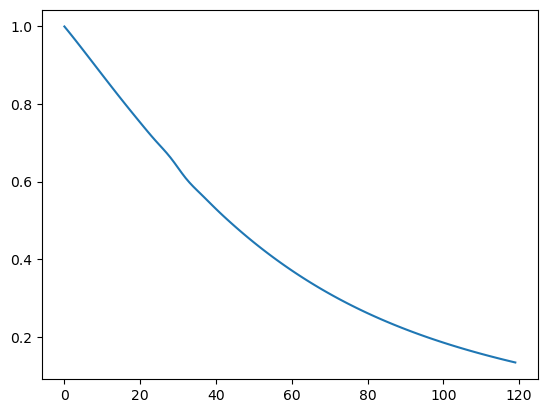

In [36]:

#plot QT for n=0 to 120
plt.plot(range(0,N*4,1),[QT(n) for n in range(0,N*4,1)])
PVQ=0
for n in range(1,N*4*4,1):
    PVQ+=QT(n)*Gamma**(n)
print(PVQ)
beta_hat=1-1/PVQ
print(beta_hat)


### finding the optimal tau
We use 
$$\tau_{T}^{*}\left(1-\tau_{T}^{*}\right)^{1-\gamma}=\frac{B_{T}+G_{T}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{G_{T+t}}{G_{T}}}{\left(1-\tau_{T}\right)^{-\gamma}\sum_{t=1}^{\infty}Q_{T}^{t}\mathbb{E}_{T}\frac{\theta_{T+t}}{\theta_{T}}}$$



In [37]:
Nm=N*4*4
def res_tau(tau):
    LHS=tau*(1-tau)**(1-gamma)
    PVG=0
    PVTheta=0
    for t in range(1,Nm):
        PVG+=QT(t)*Gamma**(t)*G_T
        PVTheta+=QT(t)*Gamma**(t)*(1-tau_T)**(-gamma)
    RHS=(B_T+PVG)/PVTheta
    return LHS-RHS

taustar=optimize.fsolve(res_tau,0.3)[0]
print("the optimal tau is")
print(taustar)

Upsilonstar=taustar*(1-tau_T)**(-gamma)*(1-taustar)**(1-gamma)
print("the optimal Upsilon is")
print(Upsilonstar)
tau_bar=taustar
Upsilon_T=Upsilonstar


the optimal tau is
0.18720540404734815
the optimal Upsilon is
0.20172501900365702


In [38]:
print("implied beta_hat = " + str(beta_hat))

print( "(Quaterly) Output to Debt = " +str(1/B_T) )
print( "Growth rate= " +str(Gamma) )
print( "Avg gross inflation= " +str(Pii) )

print( "tax rate = " +str(tau_bar) )
print( "spending to output = " +str(G_T) )
print( "revenue to output = " +str(Upsilon_T) )


implied beta_hat = 0.9870687452490858
(Quaterly) Output to Debt = 0.25
Growth rate= 1.005
Avg gross inflation= 1.0
tax rate = 0.18720540404734815
spending to output = 0.15
revenue to output = 0.20172501900365702


### Measuring $\kappa_G,\kappa_\theta,\kappa_{(r)},\sigma_f$

We measure $\mathbf{\kappa}_{(r)}, \Delta$ for using the data on returns that we have  and  interpolate for other maturities

#### Estimating the factor regressions for returns

For each maturity $k$, we now run the regression 

$$r^{k}_{t}=\alpha_k +\kappa_{(k)}  f_t+\sigma_{k}\varepsilon_{k,t}$$

and record the factor loadings $\kappa_{r}\equiv\{\kappa_{(k)}\}$, $R2$, $\Delta\equiv diag \left(\{\sigma^2_{k}\}_k\right)$


In [39]:
lag=1
X=data[['cons','factor']]
alpha=np.zeros(len(pair_of_return))
se_alpha=np.zeros(len(pair_of_return))
rho=np.zeros(len(pair_of_return))
se_rho=np.zeros(len(pair_of_return))
kappa=np.zeros(len(pair_of_return))
se_kappa=np.zeros(len(pair_of_return))
r2=np.zeros(len(pair_of_return))
Delta=np.zeros(len(pair_of_return))
Deltaraw=np.zeros(len(pair_of_return))
std_simga2 = np.zeros(len(pair_of_return))

for ret in range(len(pair_of_return)):
    Y=data[pair_of_return[ret]]
    data['lag_ret']=data[pair_of_return[ret]].shift()
    X=data[['cons','factor','lag_ret']]
    model = sm.OLS(Y[lag:],X[lag:])
    results = model.fit()
    alpha[ret]=results.params.cons
    se_alpha[ret]=results.bse.cons
    rho[ret]=results.params.lag_ret
    se_rho[ret]=results.bse.lag_ret
    kappa[ret]=results.params.factor
    se_kappa[ret]=results.bse.factor
    r2[ret]=results.rsquared
    Delta[ret]=results.resid.var()
    Deltaraw[ret]=Y.var()
     #cehck with leo
    #std_simga2[ret]=np.sqrt(2*(Y.var())**2/(len(Y)-1))
    std_simga2[ret]=np.sqrt(2*(results.resid.var())**2/(len(Y)-1))
    
#kappa=np.zeros(len(pair_of_return))
Loadings=pd.DataFrame([alpha, se_alpha, rho, se_rho, kappa,se_kappa,Delta,std_simga2,r2,Deltaraw]).T
Loadings.index=pair_of_return
Loadings.columns=['alpha','se_alpha','rho','se_rho','kappa_f','se_kappa_f','sigma2','std_simga2','R2','sigma2_raw']
Loadings['maturities']=np.array([6,9,15,21,27,33,39,45,51,57,7.5*12])/3.0
Loadings['maturities']=Loadings['maturities'].astype(int)


           alpha  se_alpha     rho  se_rho  kappa_f  se_kappa_f  sigma2  \
hprx6m    0.0863    0.0136 -0.1068  0.0429   0.0280      0.0017  0.0439   
hprx12m   0.1549    0.0252 -0.0566  0.0346   0.0745      0.0031  0.1538   
hprx18m   0.2196    0.0331 -0.0412  0.0302   0.1185      0.0041  0.2664   
hprx24m   0.2448    0.0350 -0.0425  0.0252   0.1570      0.0043  0.2999   
hprx30m   0.2840    0.0392 -0.0421  0.0227   0.1992      0.0049  0.3783   
hprx36m   0.3153    0.0395 -0.0249  0.0202   0.2304      0.0049  0.3842   
hprx42m   0.3459    0.0380 -0.0212  0.0176   0.2573      0.0047  0.3558   
hprx48m   0.3439    0.0374 -0.0077  0.0158   0.2855      0.0046  0.3454   
hprx54m   0.3720    0.0372 -0.0214  0.0147   0.3057      0.0046  0.3416   
hprx60m   0.3041    0.0429 -0.0270  0.0151   0.3449      0.0054  0.4607   
hprx510yr 0.4438    0.0299  0.0033  0.0092   0.4044      0.0037  0.2220   

           std_simga2     R2  sigma2_raw  maturities  
hprx6m         0.0039 0.5367      0.0944    

<Axes: >

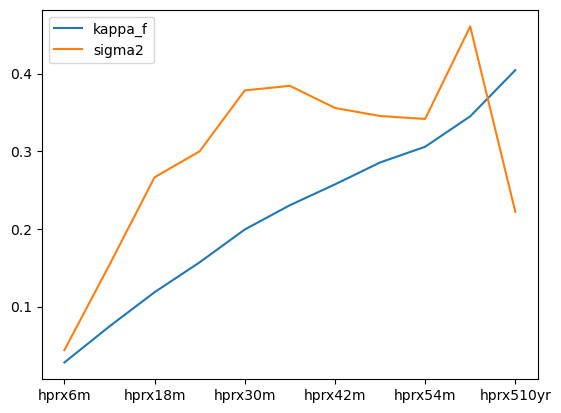

In [40]:
print (Loadings)
Loadings[['kappa_f','sigma2']].plot()    

In [41]:
Reg_table=Loadings

In [42]:
sigma2_f=data.factor.var()
print("factor variance = "+str(sigma2_f))


factor variance = 63.30751526180667


#### Estimating the factor regressions for log spending deviation

Like the returns, we also project $\hat{G}$ on the factor using 

$$\hat{G}_{t}=\ln \Gamma^G +  \hat{G}_{t-1} + \kappa_G f_t+\sigma_{G}\varepsilon_{G,t}$$



In [43]:
macrodata['ln_g_dt_lag'] = macrodata['ln_g_dt'].shift()

data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]
sel = pd.notnull(data['ln_g_dt_lag']) & (pd.notnull(
    data['factor'])) & (pd.notnull(data['ln_g_dt']))

Y = data[sel].ln_g_dt-data[sel].ln_g_dt_lag
X = data[sel][['cons', 'factor']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
print(results.summary())
kappa_G = results.params.factor
rho_G = 1.0
cov_rG_factor = Loadings.kappa_f*kappa_G*data.factor.var()

macrodata['ln_g_innv'] = macrodata['ln_g_dt'] - \
    rho_G*macrodata['ln_g_dt'].shift()
data['ln_g_innv'] = macrodata['ln_g_innv']

cov_rG_raw = macrodata[pair_of_return +
                       ['ln_g_innv']].cov().ln_g_innv[:-1].values
Loadings['cov_rG'] = cov_rG_factor
Loadings['cov_rG_raw'] = cov_rG_raw

Loadings['alpha_G'] = results.params.cons
Loadings['se_alpha_G'] = results.bse.cons

Loadings['kappa_G'] = results.params.factor
Loadings['se_alpha_G'] = results.bse.factor

Loadings['sigma_G']=results.resid.var()
## check with LEO
#Loadings['sigma_G_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
Loadings['sigma_G_se'] = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

Loadings['kappa_G'] = results.params.factor
Loadings['se_alpha_G'] = results.bse.factor

Loadings['rho_G']=rho_G
Loadings['kappa_G']=kappa_G
Loadings['se_rho_G']=np.NaN
Loadings['se_kappa_G']=results.bse.factor

Loadings["R2_G"]=results.rsquared


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     3.814
Date:                Sun, 17 Nov 2024   Prob (F-statistic):             0.0519
Time:                        18:17:53   Log-Likelihood:                -545.27
No. Observations:                 255   AIC:                             1095.
Df Residuals:                     253   BIC:                             1102.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons          -0.1769      0.129     -1.370      0.1

####  Covariance of returns $r^j_{T+1}$ and orthogonal component of deficit $\hat{G}$

We compute this two ways: using the factor structure and using the raw data 

Using the factor structure, the  T conditional covariance of $\hat{G}$ and $\boldsymbol{r}$ is given by 
$\kappa_G \kappa_f \sigma^2_{f} $

,cov_rG,cov_rG_raw
hprx6m,-0.0561,0.0045
hprx12m,-0.1495,-0.0579
hprx18m,-0.2377,-0.0793
hprx24m,-0.3150,-0.2058
hprx30m,-0.3997,-0.3724
hprx36m,-0.4624,-0.4234
hprx42m,-0.5163,-0.4942
hprx48m,-0.5729,-0.5496
hprx54m,-0.6135,-0.6729
hprx60m,-0.6921,-0.6274


<Axes: >

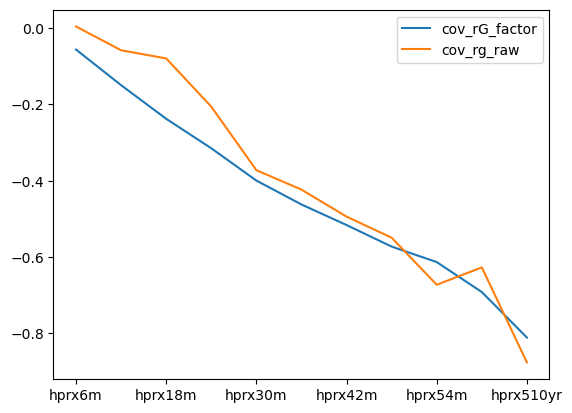

In [44]:
Loadings[['cov_rG','cov_rG_raw']]
Loadings[['cov_rG','cov_rG_raw']].plot()
plt.legend(['cov_rG_factor', 'cov_rg_raw'])
#save figure
plt.savefig(draft_path+'cov_rG.pdf')

#### Estimating the factor regressions for detrended tfp $\hat{\theta}$

Like the returns, we also project $\hat{\theta}$ on the factor using 

$$\hat{\theta}_{t}=\ln \Gamma^\theta +  \hat{\theta}_{t-1} + \kappa_{\theta} f_t+\sigma_{\theta}\varepsilon_{\theta,t}$$



In [45]:
macrodata['theta_lag'] = macrodata['theta'].shift()

data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]
sel = pd.notnull(data['theta_lag']) & (pd.notnull(
    data['factor'])) & (pd.notnull(data['theta']))

Y = data[sel].theta-data[sel].theta_lag
X = data[sel][['cons', 'factor']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
print(results.summary())
kappa_theta = results.params.factor
rho_theta = 1.0
cov_rtheta_factor = Loadings.kappa_f*kappa_theta*data.factor.var()

macrodata['theta_innv'] = macrodata['theta'] - \
    rho_theta*macrodata['theta'].shift()
data['theta_innv'] = macrodata['theta_innv']

cov_rtheta_raw = macrodata[pair_of_return +
                           ['theta_innv']].cov().theta_innv[:-1].values
Loadings['cov_rtheta'] = cov_rtheta_factor
Loadings['cov_rtheta_raw'] = cov_rtheta_raw

Loadings['rho_theta'] = rho_theta
Loadings['kappa_theta'] = kappa_theta
Loadings['se_rho_theta'] = np.NaN
Loadings['se_kappa_theta'] = results.bse.factor

Loadings['alpha_theta'] = results.params.cons
Loadings['se_alpha_theta'] = results.bse.cons

Loadings['kappa_theta'] = results.params.factor
Loadings['se_alpha_theta'] = results.bse.factor

Loadings['sigma_theta'] = results.resid.var()
# check with Leo
#Loadings['sigma_theta_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
Loadings['sigma_theta_se']  = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

Loadings['kappa_theta'] = results.params.factor
Loadings['se_alpha_theta'] = results.bse.factor


Loadings["R2_theta"] = results.rsquared




                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.109
Model:                            OLS   Adj. R-squared:                  0.105
Method:                 Least Squares   F-statistic:                     30.90
Date:                Sun, 17 Nov 2024   Prob (F-statistic):           6.87e-08
Time:                        18:17:54   Log-Likelihood:                -378.75
No. Observations:                 255   AIC:                             761.5
Df Residuals:                     253   BIC:                             768.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons          -0.1508      0.067     -2.245      0.0

,cov_rtheta,cov_rtheta_raw
hprx6m,-0.0831,-0.0862
hprx12m,-0.2214,-0.2517
hprx18m,-0.3521,-0.3691
hprx24m,-0.4666,-0.4891
hprx30m,-0.5921,-0.6146
hprx36m,-0.6851,-0.6961
hprx42m,-0.7649,-0.7764
hprx48m,-0.8488,-0.8552
hprx54m,-0.9089,-0.9666
hprx60m,-1.0254,-1.0377


<Axes: >

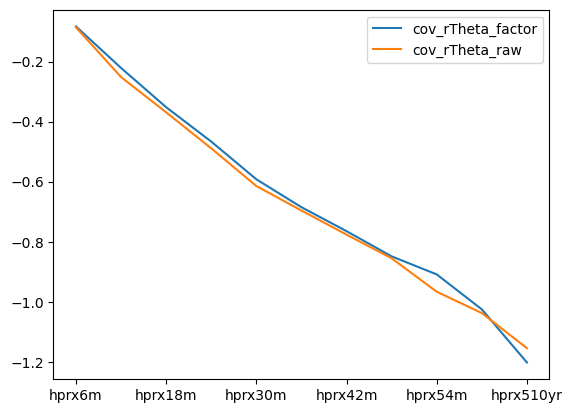

In [46]:
Loadings[['cov_rtheta','cov_rtheta_raw']]
Loadings[['cov_rtheta','cov_rtheta_raw']].plot()
plt.legend(['cov_rTheta_factor', 'cov_rTheta_raw'])
#save figure
plt.savefig(draft_path+'cov_rTheta.pdf')

#### Estimating the factor autoregression $f_t$


$$f_{t} =\alpha_{f} +\sigma_{f}\varepsilon_{f, t}$$


In [47]:
macrodata['factor_lag'] = macrodata['factor'].shift()

data = macrodata[(macrodata.index.year > start_year)
                 & (macrodata.index.year < end_year)]
sel = (pd.notnull(data['factor'])) & (pd.notnull(data['factor_lag']))

Y = data[sel].factor
X = data[sel][['cons']]
model = sm.OLS(Y[lag:], X[lag:])
results = model.fit()
print(results.summary())

Loadings['rho_factor'] = 0
Loadings['kappa_factor'] = 0
Loadings['se_rho_factor'] = np.NaN
Loadings['se_kappa_factor'] = np.NaN

Loadings['alpha_factor'] = results.params.cons
Loadings['se_alpha_factor'] = results.bse.cons


Loadings['sigma_factor'] = results.resid.var()
# check with leo
#Loadings['sigma_factor_se'] = np.sqrt(2*(Y.var())**2/(len(Y)-1))
Loadings['sigma_factor_se'] = np.sqrt(2*(results.resid.var())**2/(len(Y)-1))

Loadings["R2_factor"] = results.rsquared


                            OLS Regression Results                            
Dep. Variable:                 factor   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 17 Nov 2024   Prob (F-statistic):                nan
Time:                        18:17:54   Log-Likelihood:                -887.56
No. Observations:                 254   AIC:                             1777.
Df Residuals:                     253   BIC:                             1781.
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
cons           0.0237      0.501      0.047      0.9

### $\Sigma^{-1}$ using factor model
Now we contstruct the following inverse of covariance matrix: $\Pi_f=\Pi(\Delta,\kappa_f,\sigma^2_f)$ which is the inverse computed using the factor loadings $\kappa$ and $\Delta=diag\{\sigma^2_k\}$ 
 
 $$\Pi(\Delta,\kappa_f,\sigma^2_f)=(\sigma^2_f \kappa_f \kappa_f^{\intercal} + \Delta)^{-1}= \Delta^{-1}- \frac{\Delta^{-1}\kappa_f\kappa_f^{\intercal}\Delta^{-1} }{\frac{1}{\sigma^2_f} +\kappa_f^{\intercal} \Delta^{-1}\kappa_f }$$

In [48]:
Delta=np.diag(Loadings.sigma2.values)
def getPi(Delta,kappa,sigma2_f):
    invDelta=np.linalg.inv(Delta)
    term1=np.matmul(invDelta,kappa)
    term2=np.matmul(kappa,term1)
    Sigma=sigma2_f*np.outer(kappa,kappa) +Delta
    Pi=invDelta-np.outer(term1,term1)/((1.0/sigma2_f)+term2)
    return Pi,Sigma    
Pi,Sigma=getPi(Delta,kappa,data.factor.var())
#pd.options.display.float_format = '{:.2f}'.format


### Estimates with interpolation 

We estimate $\delta_j$ and $\sigma^2_j$ by fitting a following function 
$$f(j)=a-a\exp(-b \times j) $$

We fit $a$ and $b$ to minimize sum of squares betwen fitted and actual values of delta and sigma2

In [49]:
initial_guess = [0.3, .1]
resultkappa = optimize.minimize(lambda x:np.sum ((Loadings.kappa_f-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)) )**2) , initial_guess,method='Nelder-Mead')
print("a and b for kappa" )
resultkappa.x
func_kappa = lambda n: resultkappa.x[0]-resultkappa.x[0]*np.exp(-resultkappa.x[1]*n)

resultsigma = optimize.minimize(lambda x:np.sum ((Loadings.sigma2-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)))**2) , initial_guess,method='Nelder-Mead')
print("a and b for sigma2" )
resultsigma.x
func_sigma2 = lambda n: resultsigma.x[0]-resultsigma.x[0]*np.exp(-resultsigma.x[1]*n)
func_sigma2_raw =func_sigma2



resultalpha = optimize.minimize(lambda x:np.sum ((Loadings.alpha-(x[0]-x[0]*np.exp(-x[1]*Loadings.maturities.values)))**2) , initial_guess,method='Nelder-Mead')
print("a and b for alpha" )
resultalpha.x
func_alpha = lambda n: resultalpha.x[0]-resultalpha.x[0]*np.exp(-resultalpha.x[1]*n)


a and b for kappa


array([0.51861468, 0.05294609])

a and b for sigma2


array([0.36606713, 0.22998873])

a and b for alpha


array([0.40341883, 0.13727284])

In [50]:

maturities= Loadings.maturities
maturities_finer=np.linspace(2,N*4+1,N*4)
kappa_finer=np.zeros(len(maturities_finer))
alpha_finer=np.zeros(len(maturities_finer))

sigma2_finer=np.zeros(len(maturities_finer))
sigma2_raw_finer=np.zeros(len(maturities_finer))

#func_kappa = interp1d(maturities, Loadings.kappa_f.values,kind='linear',fill_value='extrapolate')
#func_alpha = interp1d(maturities, Loadings.alpha.values,kind='linear',fill_value='extrapolate')
#func_sigma2 = interp1d(maturities, Loadings.sigma2.values,kind='linear',fill_value='extrapolate')
#func_sigma2_raw = interp1d(maturities, Loadings.sigma2_raw.values,kind='linear',fill_value='extrapolate')

#func_kappa = lambda n: 0.1505*np.log(n)-0.0209
#func_sigma2 = lambda n: 0.1245*np.log(n)-0.0975


In [51]:


for n in maturities_finer:
    kappa_finer[int(n)-2]=func_kappa(n)
    alpha_finer[int(n)-2]=func_alpha(n)
    sigma2_finer[int(n)-2]=func_sigma2(n)        
    sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)




Delta_finer = np.diag(sigma2_finer)
Pi_finer, Sigma_finer = getPi(Delta_finer, kappa_finer, data.factor.var())
Loadings_finer = pd.DataFrame([maturities_finer, alpha_finer, kappa_finer,
                              sigma2_finer, sigma2_raw_finer]).T
Loadings_finer.columns = ['maturities', 'alpha',
                          'kappa_f', 'sigma2', 'sigma2_raw']
#N = Loadings_finer.maturities
Loadings_finer = Loadings_finer.set_index("maturities")


In [52]:
Original_points = pd.DataFrame()
Original_points["maturities"] = maturities_finer-2
for k in ["kappa_f", "alpha", "sigma2", "sigma2_raw"]:
    Original_points["{}".format(k)] = np.zeros(len(maturities_finer))
    Original_points["{}".format(k)] = np.nan
    l = 0
    for j in maturities-2:
        Original_points.loc[j, "{}".format(
            k)] = Loadings["{}".format(k)].values[l]
        l = l+1
Original_points["maturities"] = Original_points["maturities"]+2
Original_points = Original_points.loc[0:len(maturities_finer)-2, :]
Original_points.set_index("maturities", inplace=True)


### Fit for $\kappa_j$

Text(0.5, 0, 'Maturity, quarters')

(0.0, 40.0)

(0.0, 0.5)

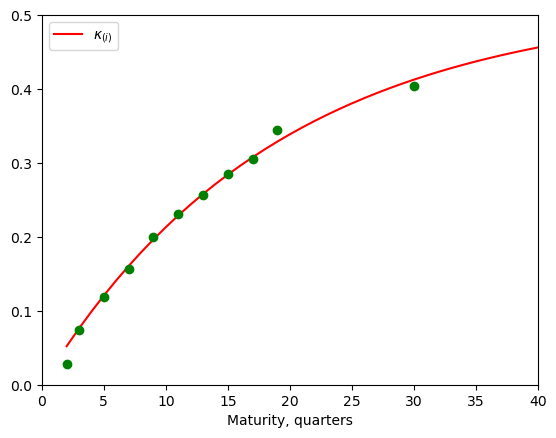

In [53]:

fig, ax = plt.subplots()
ax.set_prop_cycle(color=['red', 'green', 'blue'])
#plt.plot(Loadings_finer[['sigma2', 'kappa_f', 'cov_rX']])

#plt.plot(Original_points[['sigma2', 'kappa_f', 'cov_rX']],
#         'o')

plt.plot(Loadings_finer[[ 'kappa_f']])

plt.plot(Original_points[['kappa_f']],
         'o')

plt.xlabel("Maturity, quarters")

plt.legend([r"$\kappa_{\left(i\right)}$"])


plt.xlim(0, 40)
plt.ylim(0, .5)
plt.savefig(draft_path+"fit_kappa.png")

### Fit for $\sigma^2_j$

Text(0.5, 0, 'Maturity, quarters')

(0.0, 40.0)

(0.0, 0.5)

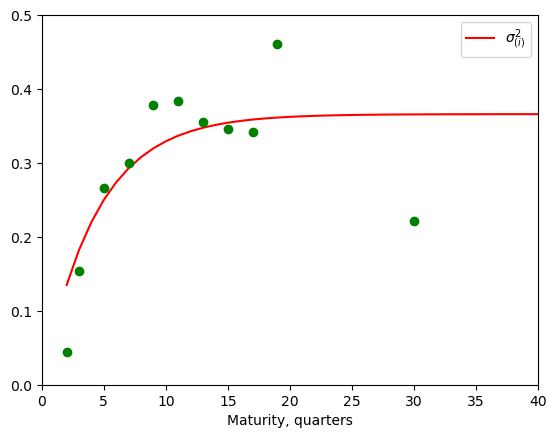

In [54]:

fig, ax = plt.subplots()
ax.set_prop_cycle(color=['red', 'green', 'blue'])
#plt.plot(Loadings_finer[['sigma2', 'kappa_f', 'cov_rX']])

#plt.plot(Original_points[['sigma2', 'kappa_f', 'cov_rX']],
#         'o')

plt.plot(Loadings_finer[[ 'sigma2']])

plt.plot(Original_points[['sigma2']],
         'o')

plt.xlabel("Maturity, quarters")

plt.legend([r"$\sigma_{\left(i\right)}^{2}$"])

plt.xlim(0, 40)
plt.ylim(0, .5)
plt.savefig(draft_path+"fit_sigma.png")

### Fit for $\frac{\kappa_j}{\sigma^2_j}$

Text(0.5, 0, 'Maturity, quarters')

(0.0, 40.0)

(0.0, 2.0)

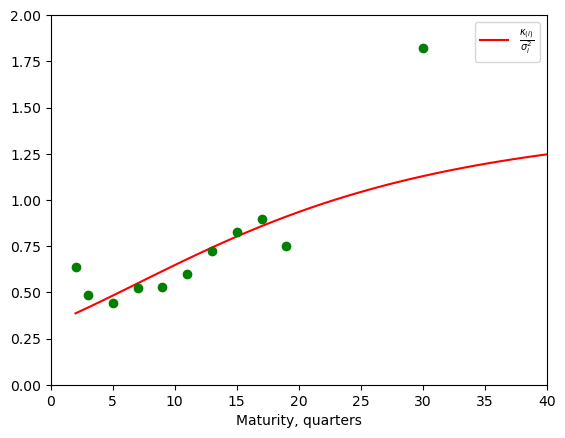

In [55]:

fig, ax = plt.subplots()
ax.set_prop_cycle(color=['red', 'green', 'blue'])
#plt.plot(Loadings_finer[['sigma2', 'kappa_f', 'cov_rX']])

#plt.plot(Original_points[['sigma2', 'kappa_f', 'cov_rX']],
#         'o')

plt.plot(Loadings_finer[ 'kappa_f']/Loadings_finer[ 'sigma2'])

plt.plot(Original_points['kappa_f']/Original_points['sigma2'],
         'o')

plt.xlabel("Maturity, quarters")

plt.legend([r"$\frac{\kappa_{\left(i\right)}}{\sigma^2_{i}}$"])

plt.xlim(0, 40)
plt.ylim(0, 2)
plt.savefig(draft_path+"fit_kappa_over_sigma.png")

### Optimal fiscal hedging portfolio
* The fiscal hedging portfolio is $\mathbf{\omega}_{T}^{\theta}+\mathbf{\omega}_{T}^{G}$ where

    $$\omega^\theta_T= \frac{T^*_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_\theta \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$

    $$\omega^G_T= - \frac{G_T}{Q^{rf}_T B_T} \sigma^2_f \kappa_G \sum_{k} (Q^k_T\Gamma^k )  \Sigma^{-1}_T \mathbf{\kappa}_{(r)}$$


<Axes: xlabel='maturities'>

Sum of hedging - portfolios = omega_h_theta   -0.3961
omega_h_G        0.1988
omega_h         -0.1973
dtype: float64


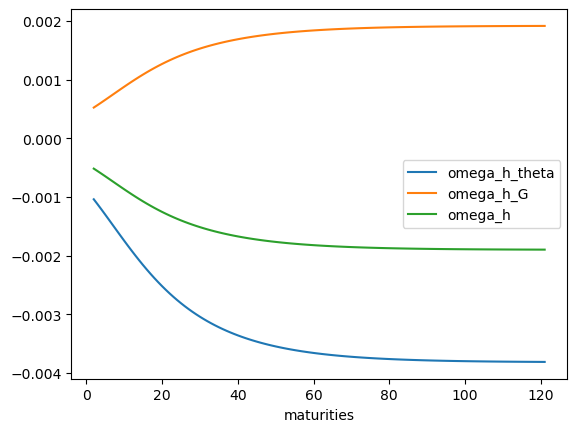

In [56]:
Qrf=QT(1)
omega_h_theta_finer=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  0*G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f
omega_h_G_finer=(1/(Qrf* B_T ))*( 0*Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f


omega_h_finer=(1/(Qrf* B_T ))*( Upsilon_T *kappa_theta / (1-  beta_hat) -  G_T *kappa_G / (1-  beta_hat) )*np.matmul(Pi_finer,kappa_finer)*sigma2_f

Loadings_finer['omega_h']=omega_h_finer
Loadings_finer['omega_h_theta']=omega_h_theta_finer
Loadings_finer['omega_h_G']=omega_h_G_finer

Loadings_finer[['omega_h_theta','omega_h_G','omega_h']].plot()

print("Sum of hedging - portfolios = "+ str(Loadings_finer[['omega_h_theta','omega_h_G','omega_h']].sum()))

### Optimal interest risk portfolio


#### Construct $\Sigma^Q$ 

In [57]:

def  get_SigmaInfty():
    Nm=N*4*4
    maturities= Loadings.maturities
    maturities_finer=np.linspace(2,Nm+1,Nm)
    kappa_finer=np.zeros(len(maturities_finer))
    alpha_finer=np.zeros(len(maturities_finer))

    sigma2_finer=np.zeros(len(maturities_finer))
    sigma2_raw_finer=np.zeros(len(maturities_finer))

    for n in maturities_finer:
            kappa_finer[int(n)-2]=func_kappa(n)
            alpha_finer[int(n)-2]=func_alpha(n)
            sigma2_finer[int(n)-2]=func_sigma2(n)        
            sigma2_raw_finer[int(n)-2]=func_sigma2_raw(n)


    Delta_finer = np.diag(sigma2_finer)
    Pi_finer, Sigma_finer = getPi(Delta_finer, kappa_finer, data.factor.var())
    np.save('Sigma_finer_tt.npy', Sigma_finer)
    np.save('maturities_finer_tt.npy', maturities_finer)
    np.save('alpha_finer_tt.npy', alpha_finer)
    np.save('kappa_finer_tt.npy', kappa_finer)
           

get_SigmaInfty()

In [58]:
SigmaInfinity = np.load('Sigma_finer_tt.npy')
maturitiesInfinity = np.load('maturities_finer_tt.npy')
alphaInfinity = np.load('alpha_finer_tt.npy')
kappaInfinity = np.load('kappa_finer_tt.npy')

sQ=np.zeros(len(maturitiesInfinity))
for k in range(len(maturitiesInfinity)):
    sQ[k]=QT(k+1)*Gamma**(k+1)


SigmaQ = SigmaInfinity[:len(maturities_finer), :]

W =  (1-beta_hat)*np.matmul(np.matmul(Pi_finer, SigmaQ),sQ)
Loadings_finer['omega_r_fin'] = W
Loadings_finer['omega_r_beta'] = (1-beta_hat)*beta_hat**(maturitiesInfinity[:len(maturities_finer)]-1 )
Loadings_finer['omega_r_QGamma'] = sQ[:len(maturities_finer)]*(1-beta_hat) # check this


print("Sum of Q- portfolio = "+ str(Loadings_finer['omega_r_fin'].sum()))
Loadings_finer['omega_r_fin'].sum()
Loadings_finer["Q"]=[QT(mat) for mat in Loadings_finer.index]


Sum of Q- portfolio = 1.0167791922940506


1.0167791922940506

In [59]:
len(maturities_finer)

120

<Axes: xlabel='maturities'>

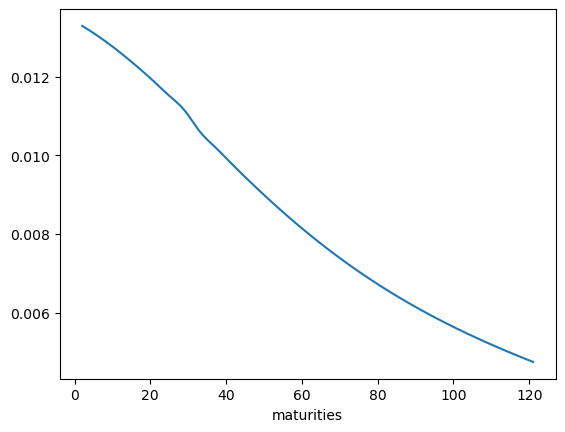

In [60]:
Loadings_finer['omega_r_fin'].plot()

<Axes: xlabel='maturities'>

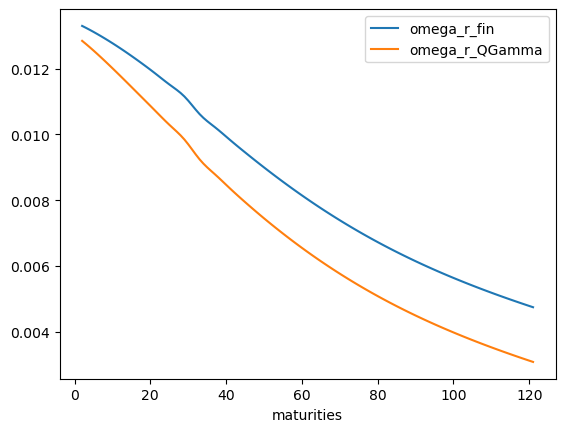

In [61]:
Loadings_finer[['omega_r_fin','omega_r_QGamma']].plot()

### sum of fiscal+hedging portfolio


<Axes: xlabel='maturities'>

fraction in the risk free bond


0.1804965390563078

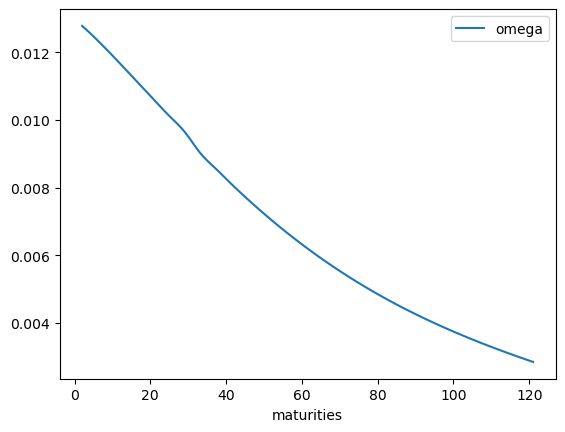

In [62]:
Loadings_finer['omega'] = Loadings_finer['omega_h'] + \
    Loadings_finer['omega_r_fin']
Loadings_finer[['omega']].plot()
print("fraction in the risk free bond")
1-Loadings_finer['omega'].sum()

Loadings_finer['omega_flipped'] = -Loadings_finer['omega_h'] + \
    Loadings_finer['omega_r_fin']

Loadings_finer.to_csv('Loadings_finer_finite.csv')


In [63]:
Loadings_finer[["omega","omega_h","omega_r_fin"]].sum()

omega          0.8195
omega_h       -0.1973
omega_r_fin    1.0168
dtype: float64

### Figure 2: TARGET PORTFOLIO, COMPONENTS, AND U.S.

In [64]:
temp=[]
usdata=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
temp=pd.DataFrame(np.ones(len(Loadings_finer.index)+1))
temp.index=range(1,len(maturities_finer)+2)
temp["omega capped"]=0
temp["omega_X"]=0
temp["omega_Q"]=0
temp["omega MF"]=0
temp["omega_US"]=0
temp["omega_QGamma"]=0

temp["(1-beta)beta^j"]=0


temp.loc[1:len(usdata),"omega_US"]=(pd.read_csv('../Data/omega_2017.csv').set_index('tmduratn_bin')/100)
temp["omega_US"]=temp["omega_US"].fillna(0)
temp.loc[2:,"omega capped"]=Loadings_finer.omega.values
temp.loc[2:,"omega_X"]=Loadings_finer.omega_h.values
temp.loc[2:,"(1-beta)beta^j"]=Loadings_finer.omega_r_beta.values
temp.loc[1,"omega capped"]=1-np.sum(Loadings_finer.omega.values)
temp.loc[2:,"omega_G"]=Loadings_finer.omega_h_G.values
temp.loc[2:,"omega_theta"]=Loadings_finer.omega_h_theta.values
temp.loc[2:,"omega_Q"]=Loadings_finer.omega_r_fin.values
temp.loc[2:,"QGamma"]=Loadings_finer.omega_r_QGamma.values
temp.loc[2:,"omega flipped"]=Loadings_finer.omega_flipped.values





In [65]:
temp.to_csv("Loadings_finer_finite.csv")

<Axes: >

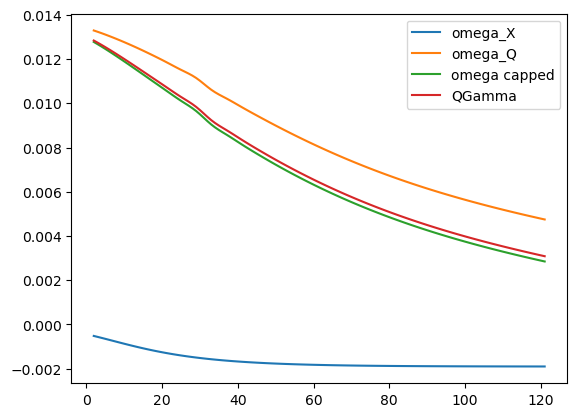

In [66]:
temp[temp.index>1][["omega_X","omega_Q","omega capped","QGamma"]].plot()

In [67]:
def plot_fig(columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], name='u',
            leg=[r"target portfolio",
                 r"U.S. portfolio", r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
                 r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"],
            T=len(temp),
            Max_y=6.0,
             col=['darkred', 'black', 'darkseagreen'],
            marker=['None' ,'None', 'None'],
            markersize=['3','1','2'],linestyle=['--', '-', '-']):
               fig, ax = plt.subplots()
               cycler = plt.cycler(linestyle=linestyle,marker=marker,markersize=markersize)
               #ax.set_prop_cycle(cycler)
               fig     = (temp[columns]*100).plot(lw=1,color=col,ax=ax).get_figure()
               columns = [x.replace('omega_', '') for x in columns]
               columns = [x.replace('gr', 'base') for x in columns]
               leg     = leg
               fig.set_dpi(200)
               plt.xlim(2, T)
               plt.ylim(-.5, Max_y)
               plt.xlabel("Maturity, quarters")
               plt.ylabel("Portfolio share, percent")
               plt.legend(leg)
               fig.savefig(draft_path+"{}.pdf".format(name))

               return fig


In [68]:
def plot_fig(
    columns=["omega capped", 'omega_US', 'omega_Q', 'omega_X'], 
    name='u',
    leg=[
        r"target portfolio",
        r"U.S. portfolio", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$", 
        r"$\left(1-\hat{\beta}\right)\mathtt{\overrightarrow{\beta}}$"
    ],
    T=None,
    Max_y=6.0,
    col=['darkred', 'black', 'darkseagreen'],
    marker=['None', 'None', 'None'],
    markersize=['3', '1', '2'],
    linestyle=['--', '-', '-.'],
    alpha=[0.5, 0.6, 0.7]
):
    # Create a copy of the data to avoid modifying the original DataFrame
    data_to_plot = temp[columns].copy() * 100

    if T is None:
        T = len(temp)

    fig, ax = plt.subplots()

    # Iterate over each column and plot with specified alpha
    for i, col_name in enumerate(columns):
        ax.plot(
            data_to_plot[col_name],  # Use the copied data
            color=col[i % len(col)], 
            lw=1, 
            linestyle=linestyle[i % len(linestyle)], 
            marker=marker[i % len(marker)], 
            markersize=float(markersize[i % len(markersize)]),
            alpha=alpha[i % len(alpha)]
        )
    
    columns = [x.replace('omega_', '') for x in columns]
    columns = [x.replace('gr', 'base') for x in columns]
    leg = leg
    
    fig.set_dpi(200)
    plt.xlim(2, T)
    plt.ylim(-0.5, Max_y)
    plt.xlabel("Maturity, quarters")
    plt.ylabel("Portfolio share, percent")
    plt.legend(leg)
    fig.savefig(draft_path + "{}.pdf".format(name))

    return fig


### Fig1a:US vs Baseline

In [69]:
#read Loadings_finer.csv

Loadings_finer_baseline=pd.read_csv('Loadings_finer.csv')
temp.loc[2:,"QGamma_baseline"]=Loadings_finer.omega_r_QGamma.values


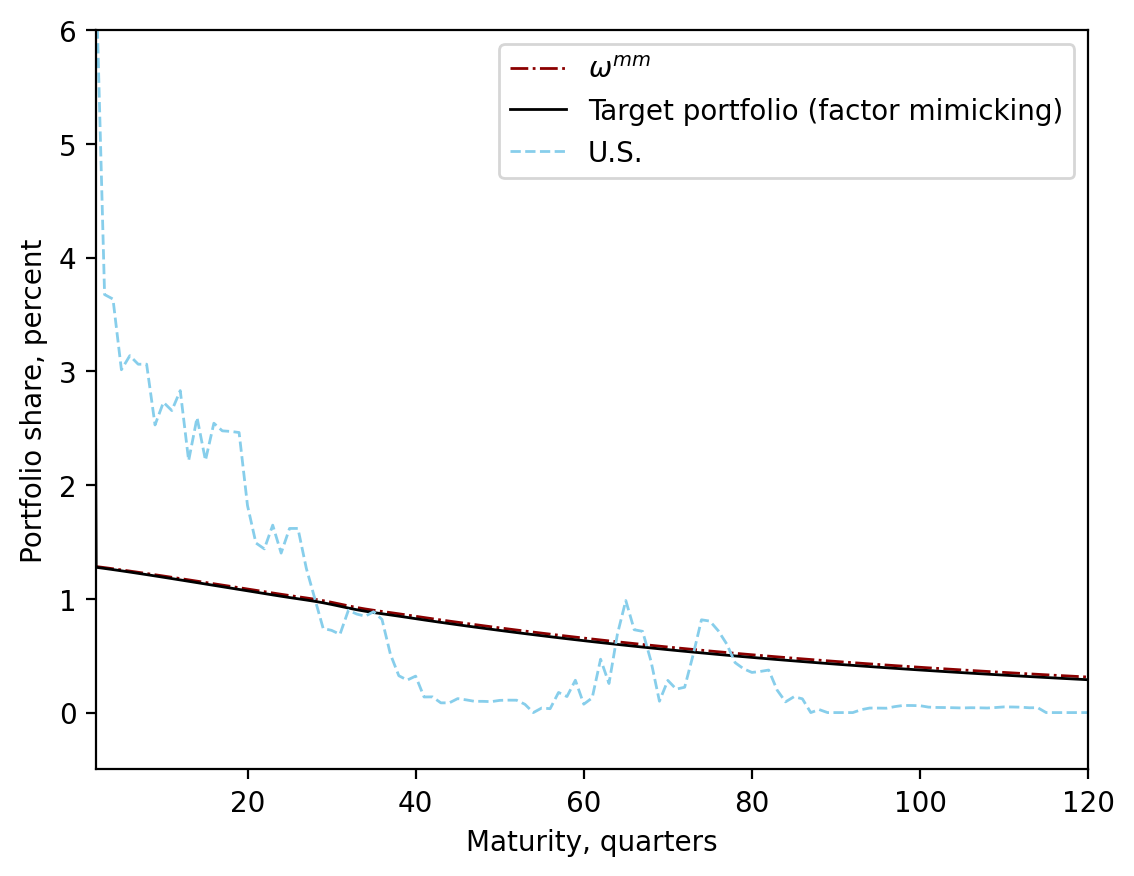

In [70]:
opt_us = plot_fig(name='opt_us_factor_mm', T=len(maturities_finer), marker=['None', 'None','None'], columns=[ 'QGamma_baseline',"omega capped",'omega_US'], leg=[ r"$\omega^{mm}$", r"Target portfolio (factor mimicking)",r"U.S."], col=['darkred', 'black','skyblue'],linestyle=['-.','-', '--'],markersize=['2','1','1'],alpha=[1,1,1])